In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simple dataset (1 feature for easy visualization)
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

# bias column
X = np.hstack([np.ones((X.shape[0], 1)), X])

print("X:\n", X)
print("y:\n", y)

X:
 [[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]
y:
 [ 2  4  6  8 10]


We add a column of 1s to handle bias (intercept).

Now:
X shape = (5, 2)
w shape = (2,)

In [3]:
w = np.zeros(X.shape[1])  # [bias, weight]
print("Initial weights:", w)

Initial weights: [0. 0.]


In [4]:
def predict(X, w):
    return np.dot(X, w)

In [5]:
y_pred = predict(X, w)
print("Predictions:", y_pred)

Predictions: [0. 0. 0. 0. 0.]


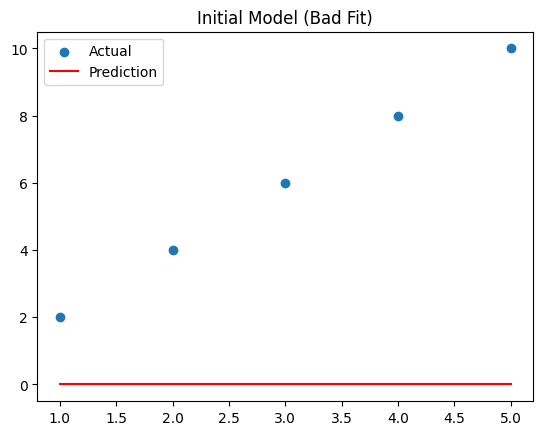

In [6]:
plt.scatter(X[:, 1], y, label="Actual")
plt.plot(X[:, 1], y_pred, color='red', label="Prediction")
plt.legend()
plt.title("Initial Model (Bad Fit)")
plt.show()

In [7]:
def compute_loss(y, y_pred):
    return np.mean((y - y_pred) ** 2)

In [8]:
def gradient_descent(X, y, w, lr=0.01, epochs=100):
    n = len(y)
    
    for i in range(epochs):
        y_pred = predict(X, w)
        
        # gradient
        gradient = (-2/n) * np.dot(X.T, (y - y_pred))
        
        # update weights
        w = w - lr * gradient
        
        if i % 10 == 0:
            loss = compute_loss(y, y_pred)
            print(f"Epoch {i}, Loss: {loss}")
    
    return w

In [9]:
w = np.zeros(X.shape[1])
w = gradient_descent(X, y, w)

print("Trained weights:", w)

Epoch 0, Loss: 44.0
Epoch 10, Loss: 0.24354526419710454
Epoch 20, Loss: 0.042973578928951574
Epoch 30, Loss: 0.03932531381522089
Epoch 40, Loss: 0.036746100994571075
Epoch 50, Loss: 0.03433955235862529
Epoch 60, Loss: 0.03209062745827491
Epoch 70, Loss: 0.029988986529728374
Epoch 80, Loss: 0.028024983751406506
Epoch 90, Loss: 0.0261896050901242
Trained weights: [0.36669053 1.8984326 ]


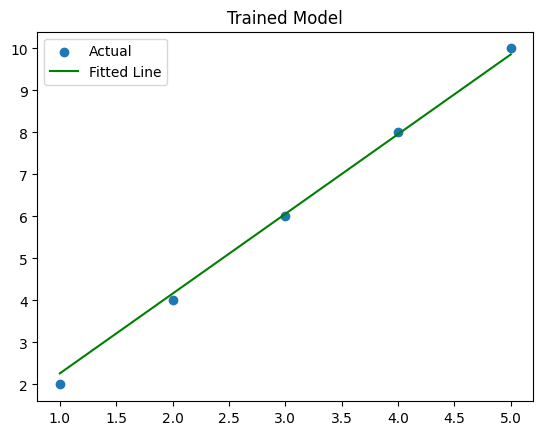

In [10]:
y_pred = predict(X, w)

plt.scatter(X[:, 1], y, label="Actual")
plt.plot(X[:, 1], y_pred, color='green', label="Fitted Line")
plt.legend()
plt.title("Trained Model")
plt.show()